# **Exploration study**

Exploration study of the variables envolved

## Preparing data

Number of training samples: 2683
First sample: {'id_EXIST': '111269', 'lang': 'es', 'text': 'tomboy como son el anime y manga pre to tomboy en la vida real ', 'meme': '111269.jpeg', 'path_memes': 'memes/111269.jpeg', 'number_annotators': 6, 'annotators': ['Annotator_277', 'Annotator_278', 'Annotator_279', 'Annotator_280', 'Annotator_281', 'Annotator_282'], 'gender_annotators': ['F', 'F', 'F', 'M', 'M', 'M'], 'age_annotators': ['18-22', '23-45', '46+', '46+', '18-22', '23-45'], 'ethnicities_annotators': ['White or Caucasian', 'Hispano or Latino', 'other', 'White or Caucasian', 'White or Caucasian', 'Hispano or Latino'], 'study_levels_annotators': ['Bachelor’s degree', 'Master’s degree', 'High school degree or equivalent', 'Bachelor’s degree', 'High school degree or equivalent', 'High school degree or equivalent'], 'countries_annotators': ['Spain', 'Spain', 'Spain', 'Italy', 'Spain', 'Portugal'], 'sensorial': {'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES2': {'rea

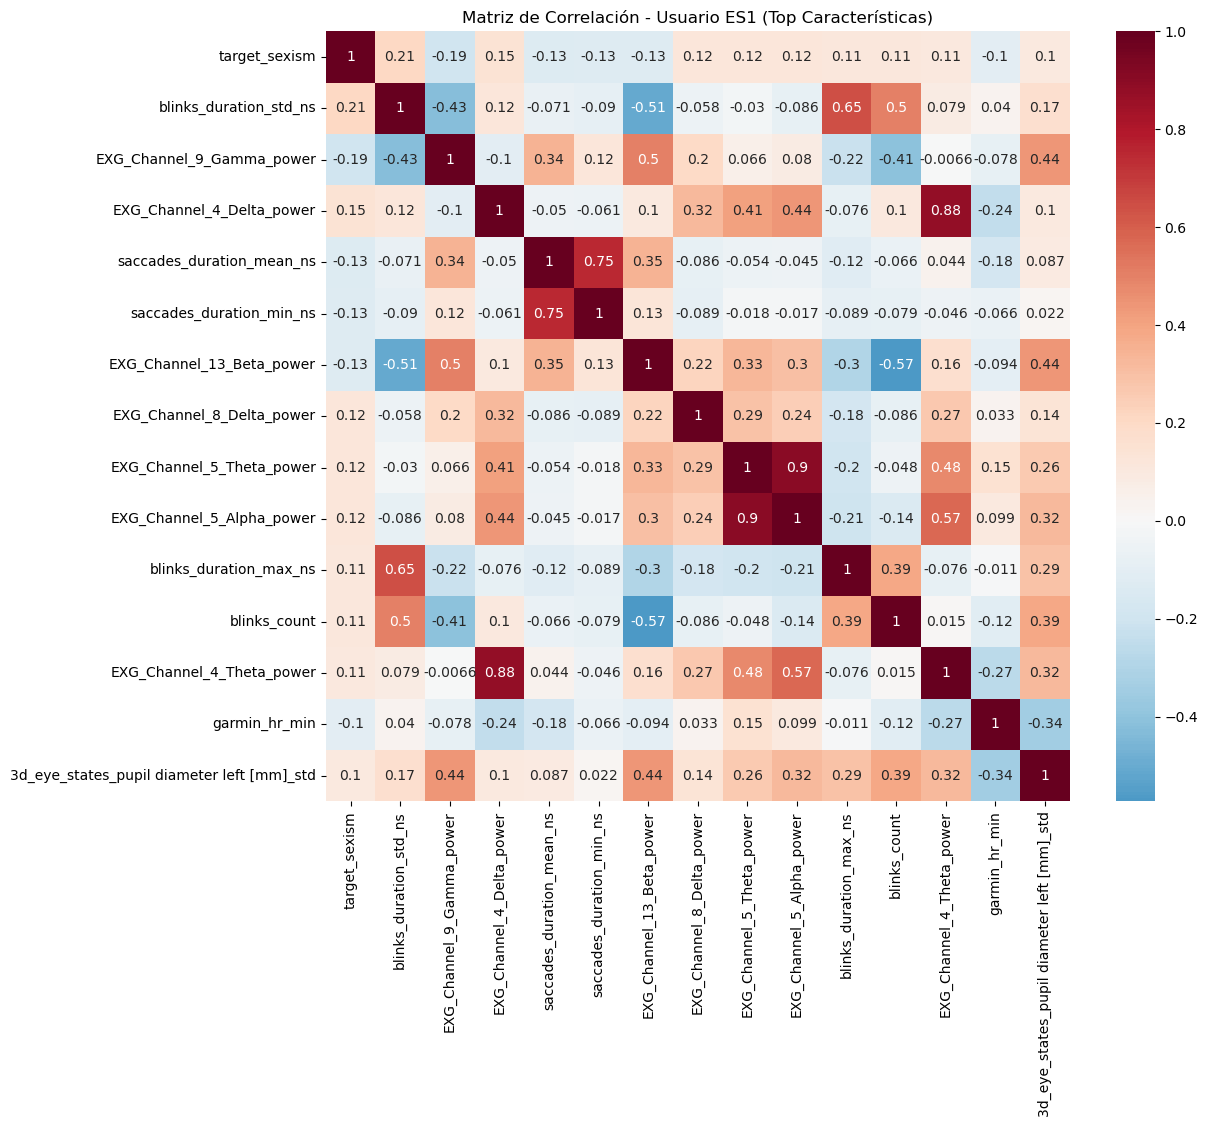

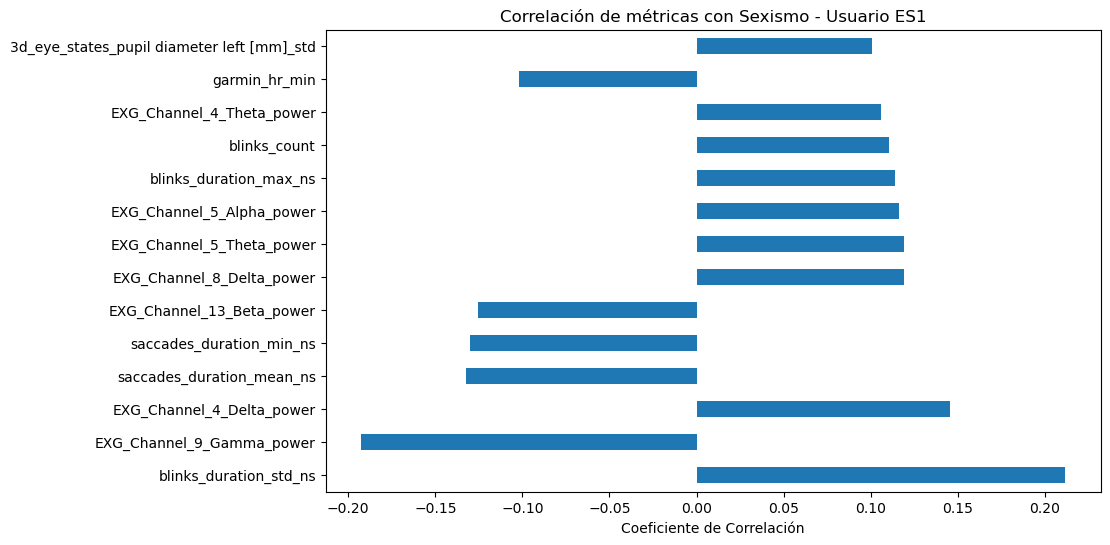

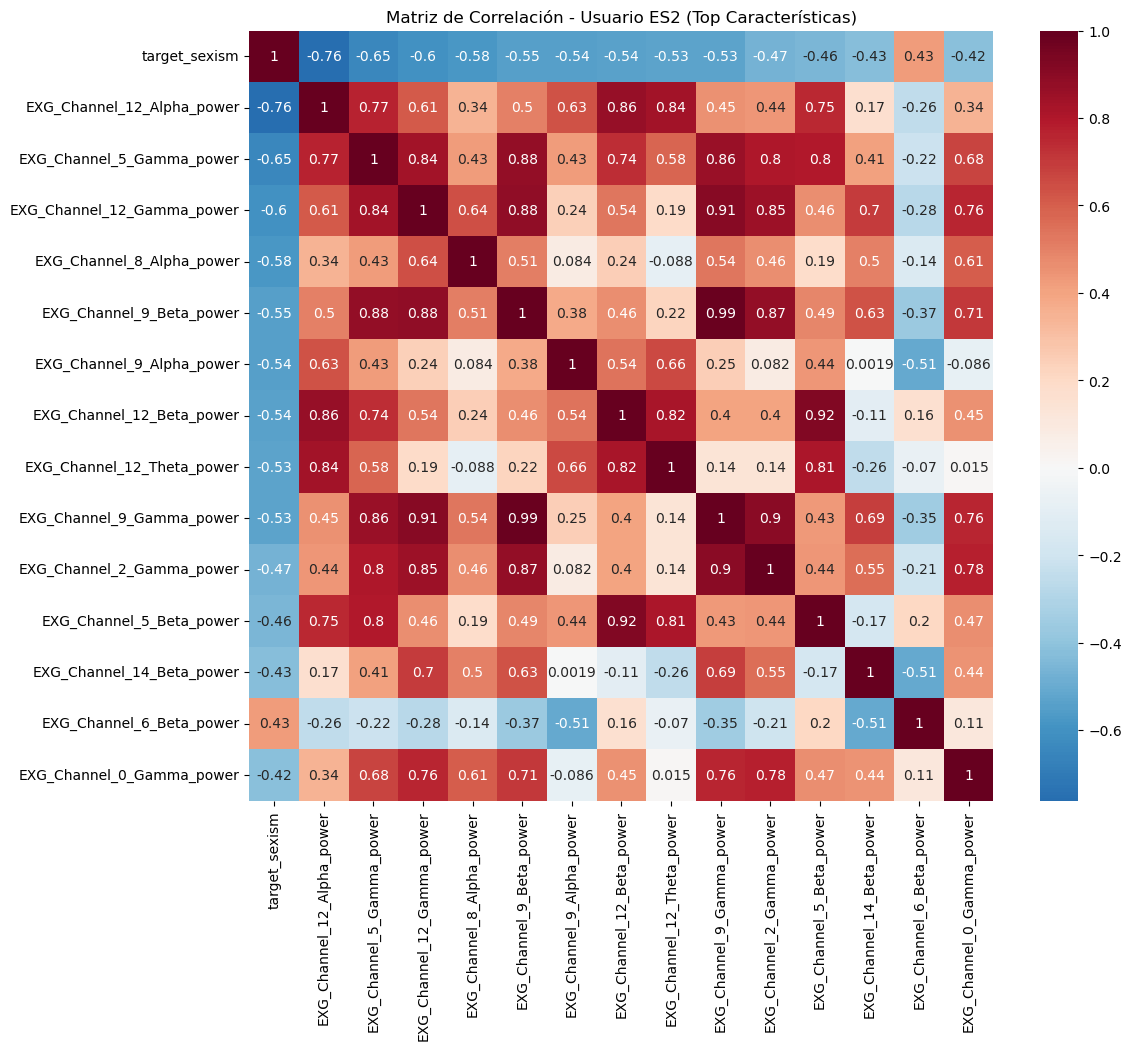

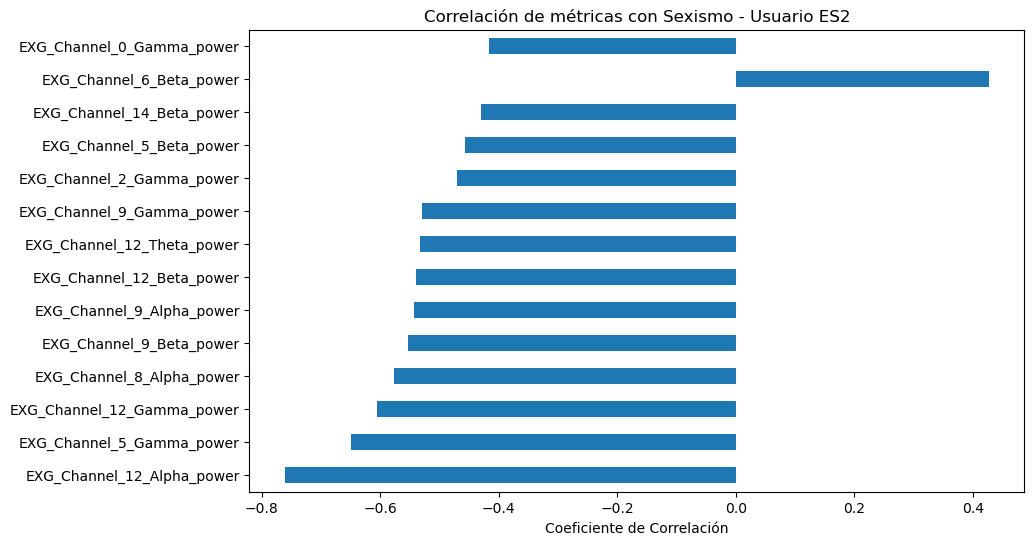

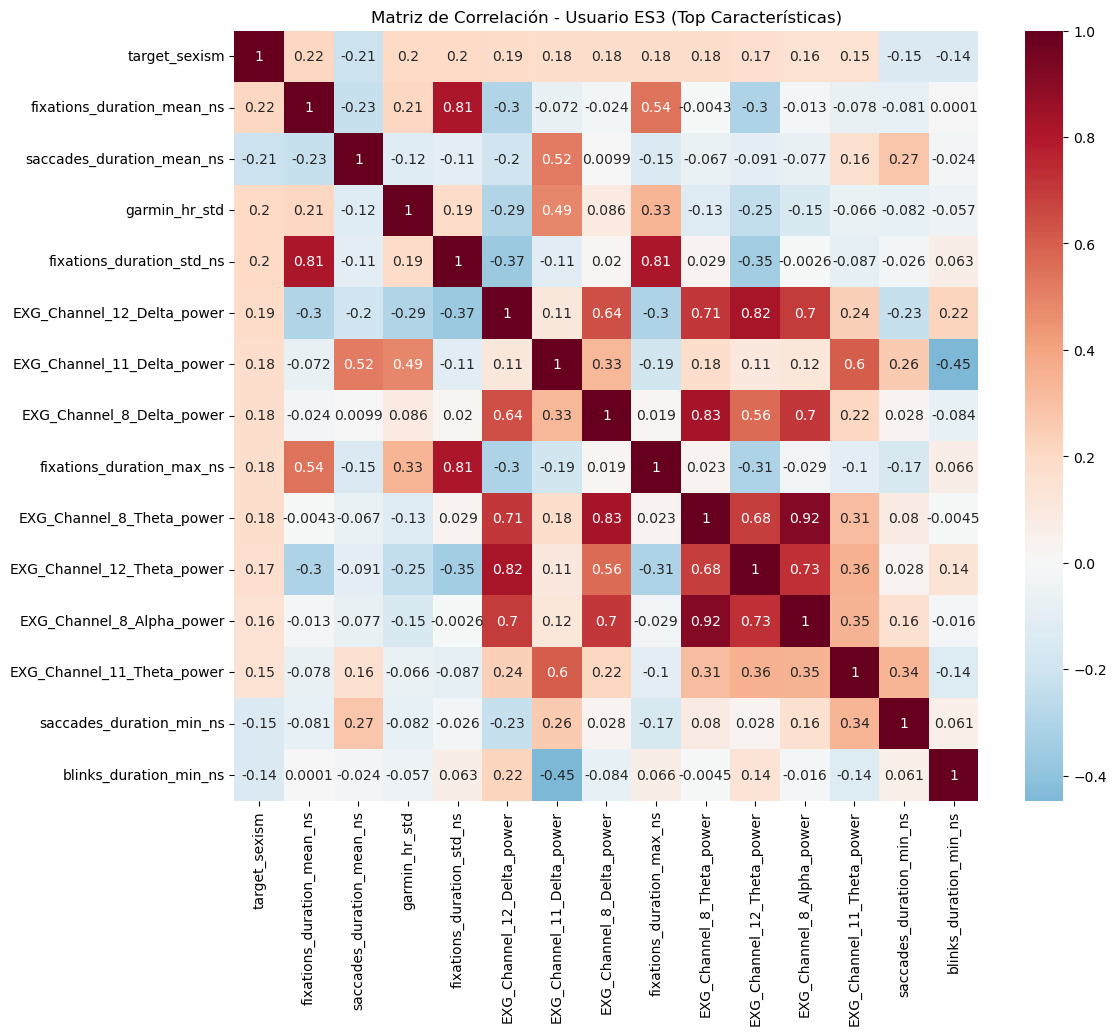

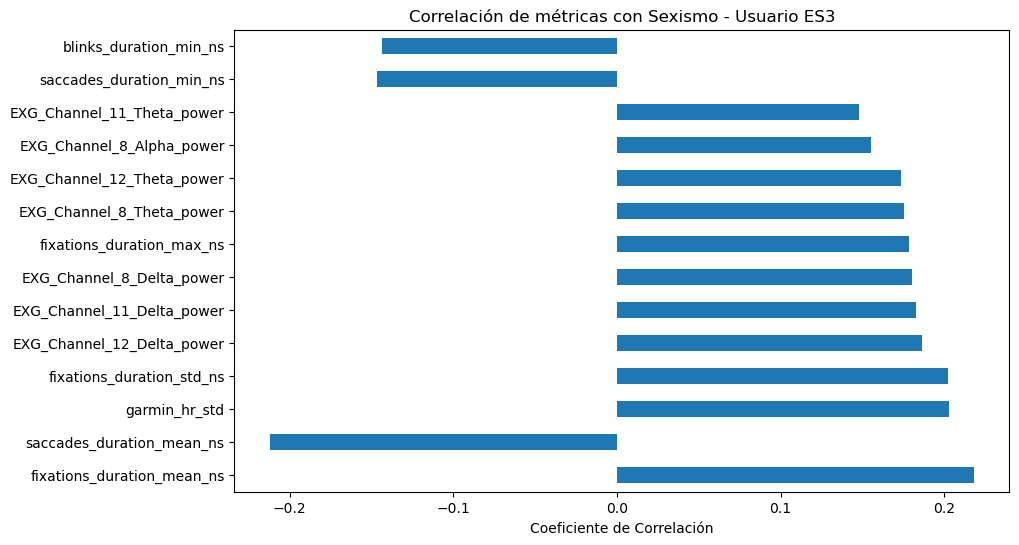

In [18]:
import json
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

with open('./lab2_materials/dataset_task2_exist2026/training.json', 'r', encoding='utf-8') as file:
    training_dict = json.load(file)

print("Number of training samples:", len(training_dict))

first_sample = training_dict[list(training_dict.keys())[0]]
print("First sample:", first_sample)

print("Keys in data:", list(first_sample.keys()))

print("Annotators values:", first_sample["annotators"])

print("Sensorial values:", first_sample["sensorial"])

print("Labels task values:", first_sample["labels_task2_1"])

# Obtaining all data wich voted labels are all YES or NO
all_yes_samples = []
all_no_samples = []
for key, sample in training_dict.items():
    if all(label == "YES" for label in sample["labels_task2_1"]):
        all_yes_samples.append(sample)
    elif all(label == "NO" for label in sample["labels_task2_1"]):
        all_no_samples.append(sample)
print("Number of samples with all YES labels:", len(all_yes_samples))
print("Number of samples with all NO labels:", len(all_no_samples))

# Obtaining a balanced dataset
balanced_all_yes_samples = all_yes_samples[:len(all_no_samples)]
print("Number of samples with all YES labels (balanced):", len(balanced_all_yes_samples))


import numpy as np

def analyze_metric(samples, metric_path):
    # metric_path podría ser: ['HR', 'by_user', 'ES2', 'garmin_hr_mean']
    values = []
    for s in samples:
        try:
            # Navegar por el diccionario sensorial
            val = s['sensorial']['modalities']
            for step in metric_path:
                val = val[step]
            values.append(val)
        except KeyError:
            continue # Algunos usuarios pueden no tener esa métrica
            
    return {
        'mean': np.mean(values),
        'std': np.std(values),
        'count': len(values)
    }

# Ejemplo de uso para el Ritmo Cardíaco de ES2
res_yes = analyze_metric(balanced_all_yes_samples, ['HR', 'by_user', 'ES2', 'garmin_hr_mean'])
res_no = analyze_metric(all_no_samples, ['HR', 'by_user', 'ES2', 'garmin_hr_mean'])

print(f"YES -> Media: {res_yes['mean']:.2f}, Desviación: {res_yes['std']:.2f}")
print(f"NO  -> Media: {res_no['mean']:.2f}, Desviación: {res_no['std']:.2f}")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def get_correlation_data(samples, user_id):
    data_list = []
    
    for s in samples:
        # 1. Calculamos el Target (Ratio de Sexismo)
        votes = s['labels_task2_1']
        target = votes.count('YES') / len(votes)
        
        # 2. Extraemos características del usuario específico
        row = {'target_sexism': target}
        
        try:
            mods = s['sensorial']['modalities']
            
            # Extraer HR
            if user_id in mods['HR']['by_user']:
                row.update(mods['HR']['by_user'][user_id])
                
            # Extraer Eye-Tracking (ET)
            if user_id in mods['ET']['by_user']:
                row.update(mods['ET']['by_user'][user_id])
                
            # Extraer EEG
            if user_id in mods['EEG']['by_user']:
                row.update(mods['EEG']['by_user'][user_id])
                
            data_list.append(row)
        except KeyError:
            continue
            
    return pd.DataFrame(data_list)

users = ['ES1', 'ES2', 'ES3']

for user in users:
    df_user = get_correlation_data(balanced_all_yes_samples + all_no_samples, user)
    
    if df_user.empty:
        print(f"No hay datos suficientes para el usuario {user}")
        continue
        
    # Calculamos la correlación de todo con el 'target_sexism'
    correlations = df_user.corr()['target_sexism'].sort_values(ascending=False)
    
    # Seleccionamos las Top 10 con más correlación (positiva o negativa)
    top_features = correlations.abs().sort_values(ascending=False).head(15).index
    df_subset = df_user[top_features]
    
    # Dibujamos la Matriz de Correlación
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_subset.corr(), annot=True, cmap='RdBu_r', center=0)
    plt.title(f"Matriz de Correlación - Usuario {user} (Top Características)")
    plt.show()
    
    # Gráfica de barras de correlación directa con la etiqueta
    plt.figure(figsize=(10, 6))
    correlations[top_features].drop('target_sexism').plot(kind='barh')
    plt.title(f"Correlación de métricas con Sexismo - Usuario {user}")
    plt.xlabel("Coeficiente de Correlación")
    plt.show()

## Feature selection and robustness tests

Objective: select biometric features to combine with tweet text. The tests below check effect size, non-parametric differences, correlations, and stability of selection across balanced resamples.


In [19]:
import json
import random
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, ttest_ind

# Load data
data_path = Path('./lab2_materials/dataset_task2_exist2026/training.json')
training_dict = json.loads(data_path.read_text())

# Strict labels: only all YES or all NO
all_yes = []
all_no = []
for s in training_dict.values():
    labels = s.get('labels_task2_1', [])
    if labels and all(l == 'YES' for l in labels):
        all_yes.append(s)
    elif labels and all(l == 'NO' for l in labels):
        all_no.append(s)

print('all_yes:', len(all_yes), 'all_no:', len(all_no))

# Balance (deterministic slice) for reference
balanced_yes = all_yes[:len(all_no)]

def build_df(samples, user_id):
    rows = []
    for s in samples:
        votes = s['labels_task2_1']
        target = votes.count('YES') / len(votes)
        row = {'target_sexism': target}
        mods = s['sensorial']['modalities']
        if user_id in mods.get('HR', {}).get('by_user', {}):
            row.update(mods['HR']['by_user'][user_id])
        if user_id in mods.get('ET', {}).get('by_user', {}):
            row.update(mods['ET']['by_user'][user_id])
        if user_id in mods.get('EEG', {}).get('by_user', {}):
            row.update(mods['EEG']['by_user'][user_id])
        rows.append(row)
    return pd.DataFrame(rows)

def cohens_d(a, b):
    a = a.dropna()
    b = b.dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    va = a.var(ddof=1)
    vb = b.var(ddof=1)
    n1 = len(a)
    n2 = len(b)
    sp = ((n1 - 1) * va + (n2 - 1) * vb) / (n1 + n2 - 2)
    if sp <= 0:
        return np.nan
    return (a.mean() - b.mean()) / np.sqrt(sp)

def cliffs_delta(a, b):
    a = a.dropna().values
    b = b.dropna().values
    if len(a) == 0 or len(b) == 0:
        return np.nan
    u = mannwhitneyu(a, b, alternative='two-sided').statistic
    n1 = len(a)
    n2 = len(b)
    return (2 * u) / (n1 * n2) - 1

def fdr_bh(pvals):
    pvals = np.array(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranks = np.arange(1, n + 1)
    q = np.empty(n)
    q[order] = pvals[order] * n / ranks
    for i in range(n - 2, -1, -1):
        q[order[i]] = min(q[order[i]], q[order[i + 1]])
    return q


all_yes: 443 all_no: 298


In [20]:
# Per-user statistical tests and effect sizes
users = ['ES1', 'ES2', 'ES3']
min_n = 50  # minimum availability for a feature to be considered

stats_by_user = {}

for user in users:
    df = build_df(balanced_yes + all_no, user)
    features = [c for c in df.columns if c != 'target_sexism']
    rows = []
    for f in features:
        n = df[f].notna().sum()
        if n < min_n:
            continue
        sub = df[['target_sexism', f]].dropna()
        if len(sub) < 3:
            continue
        x = sub[f].values
        y = sub['target_sexism'].values
        pr = pearsonr(x, y)
        sr = spearmanr(x, y)
        yes = df[df['target_sexism'] == 1][f]
        no = df[df['target_sexism'] == 0][f]
        t_p = ttest_ind(yes, no, equal_var=False, nan_policy='omit').pvalue
        m_p = mannwhitneyu(yes.dropna(), no.dropna(), alternative='two-sided').pvalue
        d = cohens_d(yes, no)
        cd = cliffs_delta(yes, no)
        rows.append((f, n, pr[0], sr[0], t_p, m_p, d, cd))
    stats_df = pd.DataFrame(rows, columns=['feature', 'n', 'pearson_r', 'spearman_r', 't_p', 'mw_p', 'cohens_d', 'cliffs_delta'])
    stats_df['mw_q'] = fdr_bh(stats_df['mw_p'].fillna(1.0).values)
    stats_by_user[user] = stats_df

# Show top features by |Cohen's d| for each user
for user, stats_df in stats_by_user.items():
    print(f'\nTop features by |d| for {user}')
    display(stats_df.sort_values('cohens_d', key=lambda s: s.abs(), ascending=False).head(12))



Top features by |d| for ES1


,feature,n,pearson_r,spearman_r,t_p,mw_p,cohens_d,cliffs_delta,mw_q
14,blinks_duration_std_ns,146,0.211908,0.221412,0.004480,0.007720,0.442859,0.256151,0.277913
77,EXG_Channel_9_Gamma_power,202,-0.192724,-0.188366,0.009104,0.007601,-0.405625,-0.225718,0.277913
48,EXG_Channel_4_Delta_power,202,0.145363,0.127751,0.030813,0.070306,0.303432,0.153083,0.639660
23,saccades_duration_mean_ns,226,-0.132538,-0.041514,0.091220,0.534168,-0.274821,-0.049479,0.872555
26,saccades_duration_min_ns,226,-0.130347,-0.109582,0.122326,0.100451,-0.270198,-0.130496,0.697638
96,EXG_Channel_13_Beta_power,202,-0.125493,-0.106605,0.090726,0.131007,-0.261238,-0.127745,0.744669
68,EXG_Channel_8_Delta_power,202,0.119210,0.039470,0.059205,0.576611,0.247965,0.047297,0.872555
54,EXG_Channel_5_Theta_power,202,0.118988,0.090130,0.071745,0.201755,0.247497,0.108003,0.757388
55,EXG_Channel_5_Alpha_power,202,0.116317,0.091452,0.061513,0.195216,0.241865,0.109586,0.757388
15,blinks_duration_max_ns,146,0.113858,0.063337,0.151339,0.446857,0.234067,0.075198,0.866088



Top features by |d| for ES2


,feature,n,pearson_r,spearman_r,t_p,mw_p,cohens_d,cliffs_delta,mw_q
22,fixations_count,163,0.169620,0.179170,0.016172,0.022682,0.351280,0.212381,0.317544
20,fixations_duration_max_ns,163,0.155079,0.153024,0.041575,0.051659,0.320388,0.181429,0.361610
27,saccades_count,178,0.150739,0.148961,0.027035,0.047669,0.311205,0.176439,0.361610
4,reaction_time,178,0.146378,0.174254,0.035133,0.020515,0.302001,0.206488,0.317544
18,fixations_duration_mean_ns,163,0.141658,0.136155,0.067977,0.083405,0.292064,0.161429,0.389225
19,fixations_duration_std_ns,163,0.134712,0.136558,0.081527,0.082494,0.277473,0.161905,0.389225
17,blinks_count,77,0.109824,0.075862,0.285534,0.512114,0.225055,0.081897,0.788518
21,fixations_duration_min_ns,163,0.098658,0.037526,0.178594,0.634133,0.202345,0.044444,0.807079
15,blinks_duration_max_ns,77,0.082727,0.095875,0.465148,0.406219,0.169082,0.114224,0.775891
11,3d_eye_states_pupil diameter right [mm]_max,178,-0.069771,-0.080114,0.369361,0.287167,-0.142746,-0.094934,0.695607



Top features by |d| for ES3


,feature,n,pearson_r,spearman_r,t_p,mw_p,cohens_d,cliffs_delta,mw_q
98,fixations_duration_mean_ns,201,0.218326,0.256887,0.000703,0.000282,0.465731,0.310293,0.030413
103,saccades_duration_mean_ns,201,-0.212104,-0.207196,0.004168,0.003401,-0.451823,-0.250271,0.122450
81,garmin_hr_std,192,0.202999,0.171058,0.001217,0.018142,0.431216,0.206475,0.201781
99,fixations_duration_std_ns,201,0.202037,0.214013,0.004846,0.002484,0.429442,0.258505,0.122450
60,EXG_Channel_12_Delta_power,198,0.186655,0.147537,0.002445,0.038499,0.388699,0.175151,0.319835
55,EXG_Channel_11_Delta_power,198,0.182487,0.166524,0.005644,0.019491,0.379716,0.197692,0.201781
100,fixations_duration_max_ns,201,0.178437,0.173560,0.011930,0.014157,0.377515,0.209642,0.196577
40,EXG_Channel_8_Delta_power,198,0.180420,0.126914,0.003552,0.075067,0.375270,0.150669,0.386060
41,EXG_Channel_8_Theta_power,198,0.175168,0.110289,0.003280,0.121933,0.363996,0.130932,0.445391
61,EXG_Channel_12_Theta_power,198,0.173305,0.193506,0.006816,0.006633,0.360004,0.229724,0.179102


In [21]:
# Stability selection via L1 Logistic Regression across balanced resamples
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

B = 50
Cs = [0.05, 0.1, 0.2]
random.seed(42)

stability_by_user = {}

for user in users:
    df_full = build_df(balanced_yes + all_no, user)
    feats = [c for c in df_full.columns if c != 'target_sexism' and df_full[c].notna().sum() >= min_n]
    if not feats:
        continue
    freq = {f: 0 for f in feats}
    total = 0
    for b in range(B):
        yes_s = random.sample(all_yes, len(all_no))
        df = build_df(yes_s + all_no, user)
        X = df[feats]
        y = (df['target_sexism'] > 0.5).astype(int)
        imputer = SimpleImputer(strategy='median')
        scaler = StandardScaler()
        X_imp = imputer.fit_transform(X)
        X_sc = scaler.fit_transform(X_imp)
        for C in Cs:
            clf = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
            clf.fit(X_sc, y)
            coefs = clf.coef_[0]
            total += 1
            for f, c in zip(feats, coefs):
                if abs(c) > 1e-6:
                    freq[f] += 1
    stability_df = pd.DataFrame({
        'feature': list(freq.keys()),
        'freq': [freq[f] / total for f in feats],
    }).sort_values('freq', ascending=False)
    stability_by_user[user] = stability_df

for user, stability_df in stability_by_user.items():
    print(f'\nTop stability features for {user}')
    display(stability_df.head(12))



Top stability features for ES1


,feature,freq
14,blinks_duration_std_ns,1.000000
77,EXG_Channel_9_Gamma_power,0.986667
6,3d_eye_states_pupil diameter left [mm]_std,0.786667
48,EXG_Channel_4_Delta_power,0.786667
68,EXG_Channel_8_Delta_power,0.766667
54,EXG_Channel_5_Theta_power,0.646667
23,saccades_duration_mean_ns,0.586667
46,EXG_Channel_3_Beta_power,0.580000
99,EXG_Channel_14_Theta_power,0.513333
94,EXG_Channel_13_Theta_power,0.493333



Top stability features for ES2


,feature,freq
22,fixations_count,0.880000
21,fixations_duration_min_ns,0.760000
20,fixations_duration_max_ns,0.700000
24,saccades_duration_std_ns,0.400000
10,3d_eye_states_pupil diameter right [mm]_std,0.320000
27,saccades_count,0.253333
25,saccades_duration_max_ns,0.233333
18,fixations_duration_mean_ns,0.233333
12,3d_eye_states_pupil diameter right [mm]_min,0.140000
1,garmin_hr_std,0.093333



Top stability features for ES3


,feature,freq
103,saccades_duration_mean_ns,1.000000
81,garmin_hr_std,1.000000
98,fixations_duration_mean_ns,0.986667
55,EXG_Channel_11_Delta_power,0.913333
86,3d_eye_states_pupil diameter left [mm]_std,0.886667
94,blinks_duration_std_ns,0.853333
60,EXG_Channel_12_Delta_power,0.800000
61,EXG_Channel_12_Theta_power,0.680000
74,EXG_Channel_14_Gamma_power,0.666667
83,garmin_hr_min,0.640000


In [22]:
# Cross-user consistency and final selection
effect_threshold = 0.2
stability_threshold = 0.5
min_users = 2

# Build a dict of effect sizes and stability
effect = {user: {} for user in users}
for user in users:
    df = stats_by_user[user]
    for _, row in df.iterrows():
        effect[user][row['feature']] = row['cohens_d']

stab = {user: {} for user in users}
for user in users:
    df = stability_by_user.get(user)
    if df is None:
        continue
    for _, row in df.iterrows():
        stab[user][row['feature']] = row['freq']

all_features = set()
for user in users:
    all_features.update(effect[user].keys())

selected = []
for f in sorted(all_features):
    eff_users = [u for u in users if f in effect[u] and abs(effect[u][f]) >= effect_threshold]
    stab_users = [u for u in users if f in stab.get(u, {}) and stab[u][f] >= stability_threshold]
    if len(eff_users) >= min_users and len(stab_users) >= min_users:
        selected.append({
            'feature': f,
            'effect_users': eff_users,
            'stability_users': stab_users
        })

selected_df = pd.DataFrame(selected)
print('Selected features (cross-user robust):', len(selected_df))
display(selected_df)

# Also show features with |d| >= 0.2 in at least 2 users (broader list)
broad = []
for f in sorted(all_features):
    eff_users = [u for u in users if f in effect[u] and abs(effect[u][f]) >= effect_threshold]
    if len(eff_users) >= min_users:
        broad.append({'feature': f, 'effect_users': eff_users})
broad_df = pd.DataFrame(broad)
print('Features with |d| >= 0.2 in >= 2 users:', len(broad_df))
display(broad_df)


Selected features (cross-user robust): 3


,feature,effect_users,stability_users
0,3d_eye_states_pupil diameter left [mm]_std,"[ES1, ES3]","[ES1, ES3]"
1,blinks_duration_std_ns,"[ES1, ES3]","[ES1, ES3]"
2,saccades_duration_mean_ns,"[ES1, ES3]","[ES1, ES3]"


Features with |d| >= 0.2 in >= 2 users: 11


,feature,effect_users
0,3d_eye_states_pupil diameter left [mm]_std,"[ES1, ES3]"
1,EXG_Channel_8_Delta_power,"[ES1, ES3]"
2,blinks_count,"[ES1, ES2, ES3]"
3,blinks_duration_std_ns,"[ES1, ES3]"
4,fixations_duration_max_ns,"[ES2, ES3]"
5,fixations_duration_mean_ns,"[ES2, ES3]"
6,fixations_duration_std_ns,"[ES2, ES3]"
7,garmin_hr_min,"[ES1, ES3]"
8,reaction_time,"[ES2, ES3]"
9,saccades_duration_mean_ns,"[ES1, ES3]"


### Conclusión (selección de biométricos)

**Núcleo recomendado (robusto entre usuarios + estable en selección):**
- `blinks_duration_std_ns`
- `saccades_duration_mean_ns`
- `3d_eye_states_pupil diameter left [mm]_std`

**Ampliación razonable (efecto en al menos 2 usuarios):**
- `fixations_duration_mean_ns`
- `fixations_duration_std_ns`
- `fixations_duration_max_ns`
- `saccades_duration_min_ns`
- `blinks_count`
- `reaction_time`
- `garmin_hr_min`

**EEG (opcional y con cautela):**
- `EXG_Channel_8_Delta_power` (solo si vas a regularizar y/o reducir dimensionalidad).

Notas:
- Las correlaciones altas en EEG de ES2 no son fiables por su baja disponibilidad.
- En general, ET y HR son más consistentes entre usuarios.
